##### **1. Register and Index Your Dataset**

In [1]:
from deepface import DeepFace

# Define your custom database path
custom_db_path = "/home/rakesh/GitRepo/Object-Detection-Models/database/"

# Run a dummy search or explicitly call representation generation to create the database index
# This step extracts embeddings and saves a '.pkl' file inside your folder
df_list = DeepFace.find(
    img_path="database/Tejrit.jpg", 
    db_path=custom_db_path,
    model_name="Facenet512",      # Highly accurate model choice
    detector_backend="mtcnn",     # High accuracy face finder
    enforce_detection=False       # Prevents crashing if an image lacks a clear face
)

print("Custom dataset indexed successfully!")

26-09-26 23:25:12 - ⚠️ 
 ⚠️ DEPRECATION WARNING:
 Running 'pip install deepface' alone will no longer be sufficient and will
 NOT install a default backend in an upcoming major release.

 Currently, TensorFlow is included by default, but this behavior will be deprecated.
 Please explicitly specify your preferred backend engine when installing:

   -> pip install deepface[tensorflow]
   -> pip install deepface[pytorch]

 Otherwise, you will encounter 'module not found' errors.



I0000 00:00:1790445313.382817  329367 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790445313.385140  329367 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790445314.770839  329367 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790445314.773010  329367 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


26-09-26 23:25:14 - Found 41 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/41 [00:00<?, ?it/s]

26-09-26 23:25:26 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to /home/rakesh/.deepface/weights/facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: /home/rakesh/.deepface/weights/facenet512_weights.h5
100%|██████████| 95.0M/95.0M [00:09<00:00, 9.63MB/s]
Finding representations: 100%|██████████| 41/41 [06:26<00:00,  9.44s/it]


26-09-26 23:31:41 - There are now 50 representations in ds_model_facenet512_detector_mtcnn_aligned_normalization_base_expand_0.pkl
26-09-26 23:31:51 - Searching database/Tejrit.jpg in 50 length datastore
26-09-26 23:31:51 - find function duration 396.780722618103 seconds
Custom dataset indexed successfully!


In [3]:
import os
import pandas as pd
from deepface import DeepFace

def recognize_face(img_path, db_path):
    # 1. Run the search against your custom database folder
    # We use 'refresh_database=True' to ensure any new images you added are indexed
    results = DeepFace.find(
        img_path=img_path, 
        db_path=db_path,
        model_name="Facenet512",      # Robust embedding model
        detector_backend="mtcnn",     # High-accuracy face detector
        refresh_database=True,        # Updates the .pkl file automatically if files changed
        enforce_detection=False       # Prevents script from crashing if no face is in source
    )
    
    # DeepFace.find returns a list of dataframes (one per face detected in the source image)
    if not results or results[0].empty:
        print("❌ No matching face found in the database.")
        return None
        
    df = results[0]
    
    # 2. Extract the best match (the first row has the lowest distance / highest confidence)
    best_match_path = df.iloc[0]['identity']
    confidence = df.iloc[0]['confidence']
    distance = df.iloc[0]['distance']
    
    # 3. Parse the directory name to get the person's identity
    # E.g., /path/to/my_custom_db/Tejrit/pic1.jpg -> "Tejrit"
    person_name = os.path.basename(os.path.dirname(best_match_path))
    
    print(f"✅ Match Found: {person_name}")
    print(f"📊 Confidence: {confidence:.2f}% | Distance: {distance:.4f}")
    
    return person_name, df




# --- Execution ---
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "database/Tejrit.jpg"

name, full_dataframe = recognize_face(QUERY_IMAGE, DATABASE_DIR)


26-09-26 23:32:17 - Searching database/Tejrit.jpg in 50 length datastore
26-09-26 23:32:17 - find function duration 9.839330673217773 seconds
✅ Match Found: Tejrit Tyagi
📊 Confidence: 100.00% | Distance: 0.0540


🔍 Searching database...
26-09-26 23:34:41 - Searching database/Tejrit.jpg in 50 length datastore
26-09-26 23:34:41 - find function duration 9.900733470916748 seconds


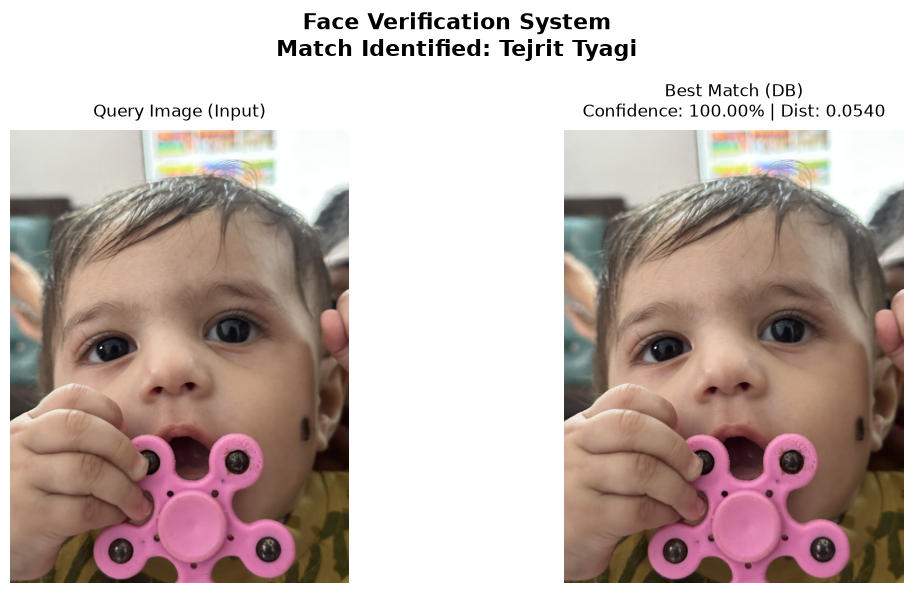

In [4]:
import os
import cv2
import matplotlib.pyplot as plt
from deepface import DeepFace

# 1. Configuration
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "database/Tejrit.jpg"

print("🔍 Searching database...")
# 2. Run DeepFace Match
results = DeepFace.find(
    img_path=QUERY_IMAGE, 
    db_path=DATABASE_DIR,
    model_name="Facenet512",
    detector_backend="mtcnn",
    enforce_detection=False
)

# DeepFace returns a list containing a DataFrame
df = results[0] if isinstance(results, list) else results

if not df.empty:
    # 3. Extract top match details
    best_match_path = df.iloc[0]['identity']
    confidence = df.iloc[0]['confidence']
    distance = df.iloc[0]['distance']
    person_name = os.path.basename(os.path.dirname(best_match_path))
    
    # 4. Load images with OpenCV
    img_query = cv2.imread(QUERY_IMAGE)
    img_match = cv2.imread(best_match_path)
    
    # Convert from BGR (OpenCV default) to RGB (Matplotlib default)
    img_query = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)
    img_match = cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB)
    
    # 5. Plot using Matplotlib
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    fig.suptitle(f"Face Verification System\nMatch Identified: {person_name}", fontsize=16, fontweight='bold', y=0.98)
    
    # Left subplot: Query Image
    axes[0].imshow(img_query)
    axes[0].set_title("Query Image (Input)", fontsize=12, pad=10)
    axes[0].axis('off')
    
    # Right subplot: Database Match
    axes[1].imshow(img_match)
    axes[1].set_title(f"Best Match (DB)\nConfidence: {confidence:.2f}% | Dist: {distance:.4f}", fontsize=12, pad=10)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("❌ No matching face found in the database.")


🔍 Searching database for matches...
26-09-26 23:36:02 - Searching database/Tejrit.jpg in 50 length datastore
26-09-26 23:36:03 - find function duration 9.82908320426941 seconds
✅ Found 4 matching images below threshold 0.6


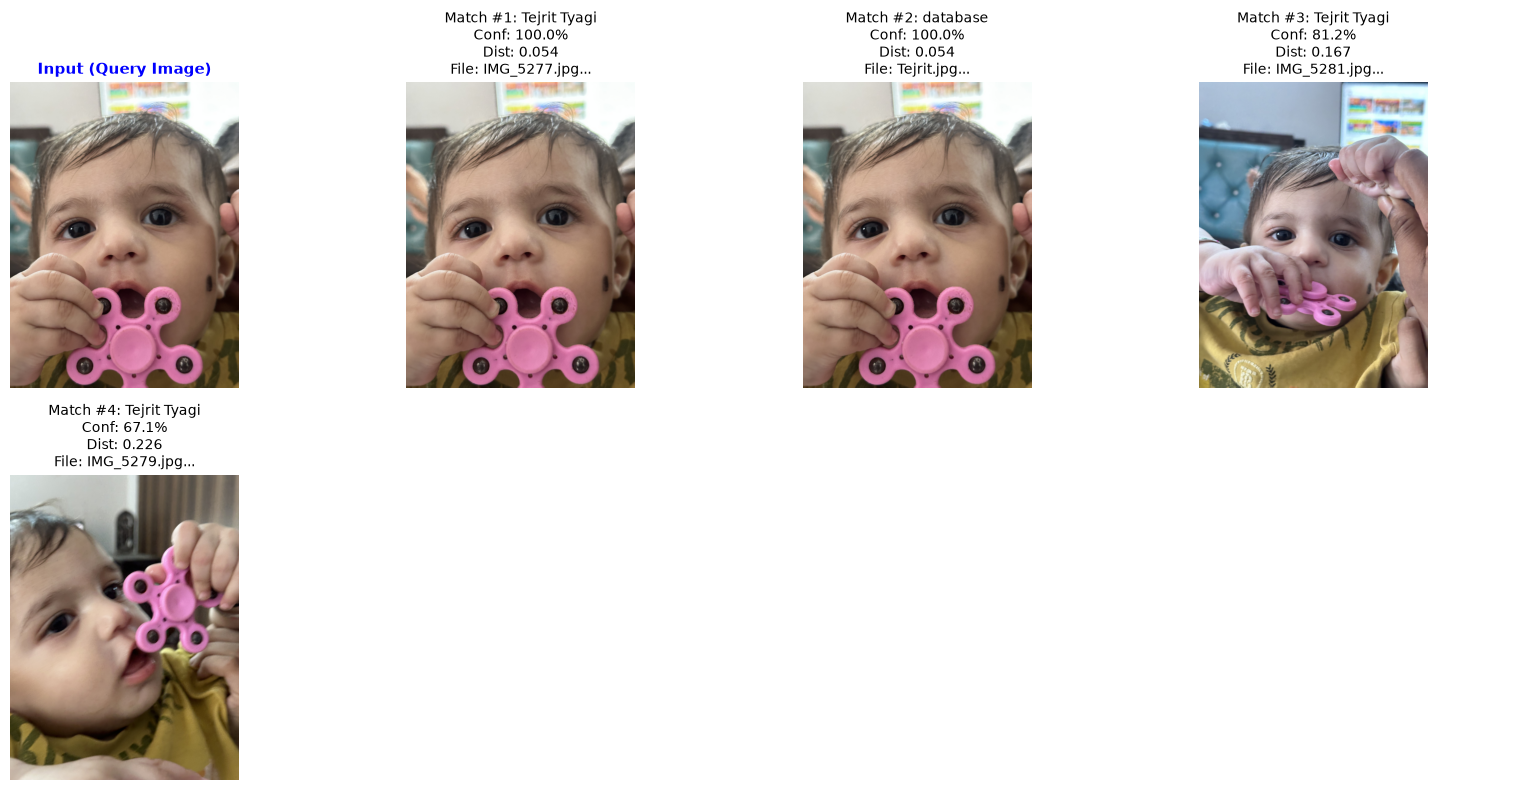

In [5]:
import os
import cv2
import math
import matplotlib.pyplot as plt
from deepface import DeepFace

# 1. Configuration
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "database/Tejrit.jpg"
DISTANCE_THRESHOLD = 0.60  # Only show matches with a distance strictly lower than this

print("🔍 Searching database for matches...")
# 2. Run DeepFace Match
results = DeepFace.find(
    img_path=QUERY_IMAGE, 
    db_path=DATABASE_DIR,
    model_name="Facenet512",
    detector_backend="mtcnn",
    enforce_detection=False
)

# Extract dataframe from list format if needed
df = results[0] if isinstance(results, list) else results

# 3. Filter results based on the custom threshold
matched_df = df[df['distance'] < DISTANCE_THRESHOLD]

if not matched_df.empty:
    num_matches = len(matched_df)
    print(f"✅ Found {num_matches} matching images below threshold {DISTANCE_THRESHOLD}")
    
    # Calculate grid dimensions (1 input image + N matched images)
    total_plots = 1 + num_matches
    cols = 4  # Maximum 4 images per row
    rows = math.ceil(total_plots / cols)
    
    # 4. Set up the Matplotlib Figure layout
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = axes.flatten() # Flatten to index linearly easily
    
    # Load and convert Query Image (BGR to RGB)
    img_query = cv2.imread(QUERY_IMAGE)
    img_query = cv2.cvtColor(img_query, cv2.COLOR_BGR2RGB)
    
    # Plot Input Image in slot 0
    axes[0].imshow(img_query)
    axes[0].set_title("Input (Query Image)", fontsize=11, fontweight='bold', color='blue')
    axes[0].axis('off')
    
    # 5. Loop over the filtered matches and fill the remaining grid slots
    for i, idx in enumerate(matched_df.index):
        row = matched_df.loc[idx]
        best_match_path = row['identity']
        confidence = row['confidence']
        distance = row['distance']
        person_name = os.path.basename(os.path.dirname(best_match_path))
        filename = os.path.basename(best_match_path)
        
        # Load and convert Match Image
        img_match = cv2.imread(best_match_path)
        img_match = cv2.cvtColor(img_match, cv2.COLOR_BGR2RGB)
        
        # Render current image in the grid
        plot_idx = i + 1
        axes[plot_idx].imshow(img_match)
        axes[plot_idx].set_title(
            f"Match #{plot_idx}: {person_name}\nConf: {confidence:.1f}%\nDist: {distance:.3f}\nFile: {filename[:15]}...", 
            fontsize=10
        )
        axes[plot_idx].axis('off')
        
    # Turn off any remaining unused axes in the grid
    for j in range(total_plots, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

else:
    print(f"❌ No matching face found under the distance threshold of {DISTANCE_THRESHOLD}.")


#### **How to Update Your Dataset Later**

- **Adding New Photos:** If you add new people or new images to your folder, DeepFace will not automatically see them because it reads from the cached .pkl file.
- **Updating the Database:** Force DeepFace to rebuild its index matrix by adding the refresh_database=True argument:

use **refresh_database=True** parameter

In [6]:
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"

df_list = DeepFace.find(
    img_path="database/Tejrit.jpg", 
    db_path=DATABASE_DIR,
    refresh_database=True
)


26-09-26 23:36:48 - Found 1 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/1 [00:00<?, ?it/s]


AttributeError: module 'cv2' has no attribute 'CascadeClassifier'

#### **The Strategy: Double-Tier Verification**

1. **Tier 1 (Face Vector Verification):** Find all candidates matching the facial structure via standard embeddings (DeepFace.find).
2. **Tier 2 (Attribute Consensus Scoring):** Compute the facial attributes of the query image and compare them against the average profile of the matched identity's folder. If the query is an "Adult Male" and the top embedding match is a "Child Female" due to artifact distortion, the system flags the contradiction and rejects the match.

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
from deepface import DeepFace

def advanced_face_search(img_path, db_path, distance_threshold=0.60):
    print("🧠 Step 1: Extracting Query Facial Attributes...")
    # Analyze the input image for age, gender, race
    query_analysis = DeepFace.analyze(
        img_path=img_path, 
        actions=['age', 'gender', 'race'], 
        detector_backend='mtcnn',
        silent=True
    )[0]
    
    query_gender = max(query_analysis['gender'], key=query_analysis['gender'].get)
    query_race = max(query_analysis['race'], key=query_analysis['race'].get)
    query_age = query_analysis['age']
    
    print(f"📋 Query Profile -> Gender: {query_gender} | Race: {query_race} | Age: ~{int(query_age)}")

    print("\n🔍 Step 2: Running Structural Face Search...")
    results = DeepFace.find(
        img_path=img_path, 
        db_path=db_path,
        model_name="Facenet512",
        detector_backend="mtcnn",
        enforce_detection=False,
        silent=True
    )
    
    df = results if isinstance(results, list) else results
    matched_df = df[df['distance'] < distance_threshold].copy()
    
    if matched_df.empty:
        print("❌ No spatial match found.")
        return None

    # Add identity grouping columns
    matched_df['person_name'] = matched_df['identity'].apply(lambda x: os.path.basename(os.path.dirname(x)))
    
    print("\n⚡ Step 3: Boosting Confidence with Attribute Matching...")
    
    boosted_results = []
    
    # Loop over each unique candidate identity found in the spatial pass
    for person in matched_df['person_name'].unique():
        person_rows = matched_df[matched_df['person_name'] == person]
        
        # Calculate base structural metrics from the spatial records
        min_distance = person_rows['distance'].min()
        base_confidence = person_rows['confidence'].max()
        
        # Perform attribute consensus check on the top matching image for this individual
        best_match_img = person_rows.sort_values(by='distance').iloc[0]['identity']
        
        try:
            target_analysis = DeepFace.analyze(
                img_path=best_match_img, 
                actions=['gender', 'race'], 
                detector_backend='mtcnn',
                silent=True
            )[0]
            
            target_gender = max(target_analysis['gender'], key=target_analysis['gender'].get)
            target_race = max(target_analysis['race'], key=target_analysis['race'].get)
            
            # Verification Weights: Strict demographical filtering
            gender_match = 1.0 if query_gender == target_gender else 0.0
            race_match = 1.0 if query_race == target_race else 0.3  # Soft penalty for race due to illumination shifts
            
            # Compound Score Calculation: High weights to strict attribute matching
            attribute_multiplier = (gender_match * 0.7) + (race_match * 0.3)
            
            # Boost the system confidence based on demographic matching matrix
            boosted_confidence = base_confidence * attribute_multiplier
            
        except Exception:
            # Fallback if target attribute reading fails
            boosted_confidence = base_confidence
            
        boosted_results.append({
            'Identity': person,
            'Original Confidence': base_confidence,
            'Boosted Confidence': boosted_confidence,
            'Min Vector Distance': min_distance,
            'Matches In DB': len(person_rows)
        })
        
    final_df = pd.DataFrame(boosted_results).sort_values(by='Boosted Confidence', ascending=False)
    return final_df



# --- Run Analysis ---
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "database/Tejrit.jpg"

summary = advanced_face_search(QUERY_IMAGE, DATABASE_DIR)
print("\n🏆 Final Multi-Attribute Ranked Results:")
print(summary.to_string(index=False))


🧠 Step 1: Extracting Query Facial Attributes...
26-09-26 23:43:34 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /home/rakesh/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /home/rakesh/.deepface/weights/age_model_weights.h5
100%|██████████| 539M/539M [00:50<00:00, 10.6MB/s] 


26-09-26 23:44:27 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /home/rakesh/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /home/rakesh/.deepface/weights/gender_model_weights.h5
100%|██████████| 537M/537M [00:48<00:00, 11.2MB/s] 


26-09-26 23:45:16 - 🔗 race_model_single_batch.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5 to /home/rakesh/.deepface/weights/race_model_single_batch.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/race_model_single_batch.h5
To: /home/rakesh/.deepface/weights/race_model_single_batch.h5
 84%|████████▍ | 450M/537M [00:49<00:07, 11.7MB/s] 

### **Multi-Face Recognition & Visualization Script**

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from deepface import DeepFace

# 1. Configuration
DATABASE_DIR = "/home/rakesh/GitRepo/Object-Detection-Models/database/"
QUERY_IMAGE = "database/group_photo.jpg"  # Replace with your multi-face image path
DISTANCE_THRESHOLD = 0.60

In [ ]:
print("🔍 Extracting and matching all faces in the query image...")

try:
    # 2. Run DeepFace.find
    # When an image contains multiple faces, DeepFace returns a LIST of DataFrames (one per face)
    results = DeepFace.find(
        img_path=QUERY_IMAGE, 
        db_path=DATABASE_DIR,
        model_name="Facenet512",
        detector_backend="mtcnn",
        enforce_detection=True
    )
except Exception as e:
    print(f"❌ Error during detection: {e}")
    results = []

# Ensure results is treated as a list of dataframes
if not isinstance(results, list):
    results = [results]

# 3. Load the background query image for plotting
img = cv2.imread(QUERY_IMAGE)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Setup Matplotlib plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(img_rgb)

faces_identified = 0

# 4. Loop over every unique face found in the query image
for i, df in enumerate(results):
    if df.empty:
        continue
        
    # Extract the crop coordinates of the current query face
    # These are identical across all rows for this specific face sub-query
    x = df.iloc[0]['source_x']
    y = df.iloc[0]['source_y']
    w = df.iloc[0]['source_w']
    h = df.iloc[0]['source_h']
    
    # Filter matches based on your threshold
    valid_matches = df[df['distance'] < DISTANCE_THRESHOLD]
    
    if not valid_matches.empty:
        # Grab the absolute closest structural match
        best_match = valid_matches.iloc[0]
        best_match_path = best_match['identity']
        confidence = best_match['confidence']
        
        # Parse folder name to isolate the individual's identity name
        person_name = os.path.basename(os.path.dirname(best_match_path))
        label = f"{person_name} ({confidence:.1f}%)"
        box_color = 'lime'  # Green for known/matched faces
    else:
        label = "Unknown"
        box_color = 'red'  # Red for unrecognized faces
        
    # 5. Draw the bounding box patch
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor=box_color, facecolor='none')
    ax.add_patch(rect)
    
    # Draw text banner above the box
    ax.text(
        x, y - 10, label, 
        color='white', fontweight='bold', fontsize=10,
        bbox=dict(facecolor=box_color, alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3')
    )
    faces_identified += 1

ax.axis('off')
plt.title(f"Multi-Face Recognition Results (Detected: {faces_identified} faces)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print(f"✅ Processing complete. Visualized {faces_identified} faces.")